In [2]:
import numpy as np
from popsummary.popresult import PopulationResult
from matplotlib import pyplot as plt
import json
import sys

repo_home = '../../'
sys.path.append(repo_home+'scripts/fig_scripts/spins')
import plotting_functions_simona as pf
pf.setup()

In [3]:
# load the bspline data
with open(repo_home+'analyses/jaxen/path_to_popsummary_files.txt', "r") as file:
    fname = file.read().split('\n')[2] # third line in the file
    result_bspline = PopulationResult(fname=fname)

# load the default data
with open(repo_home+'analyses/matt/popsummary_filepath_mag_truncnorm_iid_tilt_isotropic_truncnorm_nid.txt', "r") as file:
    fname = file.read().split('\n')[0] # first line in the file
    result_default = PopulationResult(fname=fname)

# rates on grids
chi_grid_bspline, chi_rates_bspline  = result_bspline.get_rates_on_grids('p(a)')
chi_grid_default, chi_rates_default  = result_default.get_rates_on_grids('a')

In [4]:
color1 = '#289e49' # bspline
color2 = '#2798e3' # default

figsize = (1.3*pf.FIG_WIDTH/2, 0.8*pf.FIG_WIDTH/2)

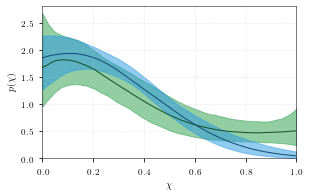

In [5]:
fig, ax = plt.subplots(1,1,figsize=figsize)

## spin magnitudes
pf.plot_traces(ax, chi_grid_bspline, chi_rates_bspline, color=color1, normed=False, fill_between=True)
pf.plot_traces(ax, chi_grid_default, chi_rates_default, color=color2, normed=False, fill_between=True)

ax.set_xlabel(r'$\chi$')
ax.set_ylabel(r'$p(\chi)$')
ax.set_ylim(0, )
ax.set_xlim(0, 1)

ax.grid(color='silver', alpha=0.5, ls=':')

0.8 [0.10300237 0.20848191 0.35933477] [0.31697432 0.48049264 0.70110239]
0.9 [0.03848008 0.10440028 0.22175574] [0.29765609 0.48367469 0.69281775]
1.0 [0.01264751 0.04781113 0.12921957] [0.24211903 0.51239914 0.92889778]


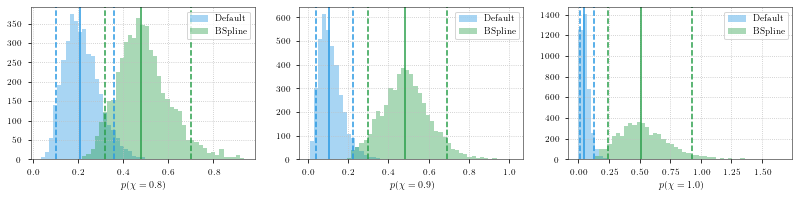

In [9]:
# plot histogram of values at chi = 0.8, 0.9, 1.0

figsize = (1.3*3*pf.FIG_WIDTH/2, 0.8*pf.FIG_WIDTH/2)
fig, axes = plt.subplots(1,3,figsize=figsize)

for chi, ax in zip([0.8, 0.9, 1.0], axes):

    i_default = np.argmin(np.abs(chi_grid_default - chi))
    p_at_chi_default = chi_rates_default[:,i_default]

    i_bspline = np.argmin(np.abs(chi_grid_bspline - chi))
    p_at_chi_bspline = chi_rates_bspline[:,i_bspline]

    bins = np.linspace(min(p_at_chi_default), max(p_at_chi_bspline), 50)
    ax.hist(p_at_chi_default, bins=bins, alpha=0.4, color=color2, label='Default')
    ax.hist(p_at_chi_bspline, bins=bins, alpha=0.4, color=color1, label='BSpline')

    quants_default = np.quantile(p_at_chi_default, [0.05, 0.5, 0.95])
    quants_bspline = np.quantile(p_at_chi_bspline, [0.05, 0.5, 0.95])

    print(chi, quants_default, quants_bspline)

    for q1, q2, ls in zip(quants_default, quants_bspline, ('--', '-', '--')):

        ax.axvline(q1, ls=ls, color=color2)
        ax.axvline(q2, ls=ls, color=color1)

    ax.set_xlabel(fr'$p(\chi={chi})$')
    ax.legend()
    ax.grid(color='silver',ls=':')

plt.show()


84.66155385128374
95.8652884294765
97.7992664221407


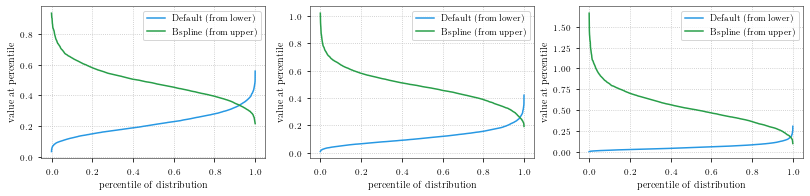

In [27]:
## find percentile at which they are discrepant 
macroData = {}

chi_list = [0.8, 0.9, 1.0]
n = len(chi_list)

figsize = (1.3*n*pf.FIG_WIDTH/2, 0.8*pf.FIG_WIDTH/2)
fig, axes = plt.subplots(1,n,figsize=figsize)

for chi, ax in zip(chi_list, axes):

    i_default = np.argmin(np.abs(chi_grid_default - chi))
    p_at_chi_default = chi_rates_default[:,i_default]

    i_bspline = np.argmin(np.abs(chi_grid_bspline - chi))
    p_at_chi_bspline = chi_rates_bspline[:,i_bspline]

    quant_array = np.linspace(0,1,3000)
    quants_default = np.quantile(p_at_chi_default, quant_array)
    quants_bspline = np.quantile(p_at_chi_bspline, quant_array)

    ax.plot(quant_array, quants_default, color=color2, label='Default (from lower)')
    ax.plot(quant_array, quants_bspline[::-1], color=color1, label='Bspline (from upper)')

    ax.set_xlabel('percentile of distribution')
    ax.set_ylabel('value at percentile')
    ax.legend()
    ax.grid(color='silver',ls=':')

    # print value at which they cross over
    mask = np.where(quants_default >= quants_bspline[::-1])
    x = 100 * quant_array[mask][0]
    y = 100 - 2*(100-x)
    print(y)

    macroData[f'discrepancy percentile for chi={chi}'] = int(np.round(y))

plt.show()

0.8307236842105263


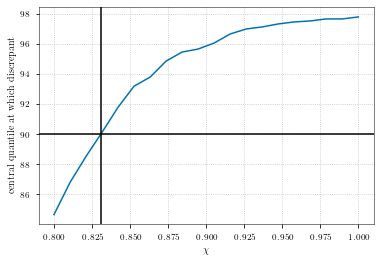

In [33]:

chi_list = np.linspace(0.8, 1, 20)
discrepancies = []

for chi in chi_list:

    i_default = np.argmin(np.abs(chi_grid_default - chi))
    p_at_chi_default = chi_rates_default[:,i_default]

    i_bspline = np.argmin(np.abs(chi_grid_bspline - chi))
    p_at_chi_bspline = chi_rates_bspline[:,i_bspline]

    quant_array = np.linspace(0,1,3000)
    quants_default = np.quantile(p_at_chi_default, quant_array)
    quants_bspline = np.quantile(p_at_chi_bspline, quant_array)

    # print value at which they cross over
    mask = np.where(quants_default >= quants_bspline[::-1])
    x = 100 * quant_array[mask][0]
    y = 100 - 2*(100-x)
    discrepancies.append(y)

discrepancies = np.asarray(discrepancies)

chi_at_d90 = np.interp(90, discrepancies, chi_list)
macroData['chi at discrepancy=90'] =  np.round(chi_at_d90,2)
print(chi_at_d90)

plt.figure()
plt.plot(chi_list, discrepancies)
plt.xlabel(r'$\chi$')
plt.ylabel('central quantile at which discrepant')
plt.axvline(chi_at_d90, color='k')
plt.axhline(90, color='k')
plt.grid(color='silver',ls=':')
plt.show()

In [34]:
macroData

{'discrepancy percentile for chi=0.8': 85,
 'discrepancy percentile for chi=0.9': 96,
 'discrepancy percentile for chi=1.0': 98,
 'chi at discrepancy=90': 0.83}

In [35]:
with open(repo_home+'macro_data/defaultVersusBSplineSpinMagnitudes.json', 'w') as f:
    json.dump(macroData, f)